# Week 1 示例：Matplotlib 可视化

- 作者：共享仓库示例
- 日期：2026-07-14
- 来源：`暑期居家集训学习计划.md` → Week 1 → Matplotlib 可视化
- 适用周次：Week 1
- 分类：Matplotlib / sklearn
- 关键词：训练曲线、混淆矩阵、ROC、t-SNE
- 运行环境：Python 3.10+、NumPy、Matplotlib、scikit-learn
- 适合读者：已经会基本 Python 和 NumPy 的初学者

## 学习目标

1. 画出实验中常见的五类图表。
2. 为图表补充标题、坐标轴、图例和必要说明。
3. 掌握将图片保存为报告素材的基本方式。

> 这是《实验室新生暑期居家集训学习计划》代码的示例切片，不是 Week 1 完整作业。

本 Notebook 使用可复现的模拟实验数据，完成 5 类论文常用图表：训练曲线、混淆矩阵、模型性能柱状图、ROC 曲线和二维特征散点图。重点不是手写每一个底层细节，而是掌握图表在论文和实验报告中的表达方式。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})


## 1. 训练 Loss / Accuracy 折线图

训练曲线用于观察模型是否正常收敛。Loss 持续下降、Accuracy 持续上升，通常说明模型正在学习有效模式；如果验证集曲线开始恶化，则可能出现过拟合。

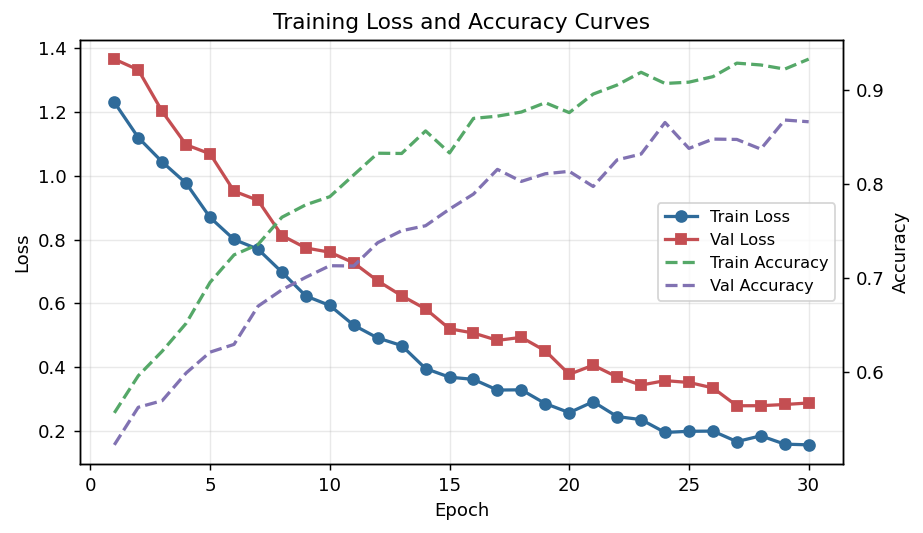

In [2]:
epochs = np.arange(1, 31)
train_loss = 1.25 * np.exp(-epochs / 11) + 0.08 + np.random.normal(0, 0.018, size=epochs.size)
val_loss = 1.35 * np.exp(-epochs / 13) + 0.13 + np.random.normal(0, 0.024, size=epochs.size)
train_acc = 0.52 + 0.43 * (1 - np.exp(-epochs / 10)) + np.random.normal(0, 0.008, size=epochs.size)
val_acc = 0.49 + 0.40 * (1 - np.exp(-epochs / 12)) + np.random.normal(0, 0.012, size=epochs.size)

fig, ax1 = plt.subplots(figsize=(7.2, 4.2))
ax1.plot(epochs, train_loss, marker="o", linewidth=1.8, label="Train Loss", color="#2F6B9A")
ax1.plot(epochs, val_loss, marker="s", linewidth=1.8, label="Val Loss", color="#C44E52")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.28)

ax2 = ax1.twinx()
ax2.plot(epochs, train_acc, linestyle="--", linewidth=1.8, label="Train Accuracy", color="#55A868")
ax2.plot(epochs, val_acc, linestyle="--", linewidth=1.8, label="Val Accuracy", color="#8172B2")
ax2.set_ylabel("Accuracy")

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="center right")
ax1.set_title("Training Loss and Accuracy Curves")
fig.tight_layout()
fig.savefig(FIG_DIR / "week1_training_curve.png")
plt.show()


## 2. 混淆矩阵热力图

混淆矩阵用于分析分类模型具体错在哪里。对角线数值越高，说明对应类别被正确识别得越多；非对角线数值越高，则说明模型容易把某一类误判成另一类。

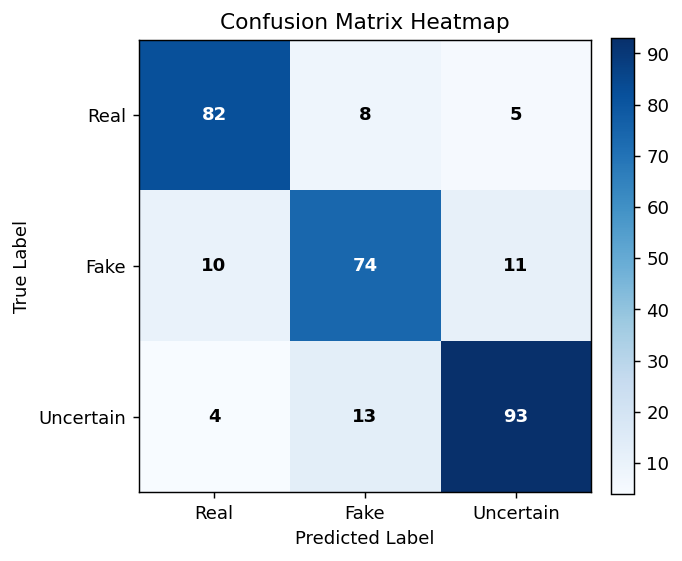

In [3]:
cm = np.array([
    [82, 8, 5],
    [10, 74, 11],
    [4, 13, 93]
])
labels = ["Real", "Fake", "Uncertain"]

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(len(labels)), labels=labels)
ax.set_yticks(np.arange(len(labels)), labels=labels)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix Heatmap")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() * 0.55 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontweight="bold")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIG_DIR / "week1_confusion_matrix.png")
plt.show()


## 3. 模型性能对比柱状图

柱状图适合展示多个模型或多个实验设置之间的指标差异。这里比较了 Text、Image、Fact 和 Fusion 四种输入设置，Fusion 的 Accuracy 与 F1 更高，说明多源信息融合可能带来性能收益。

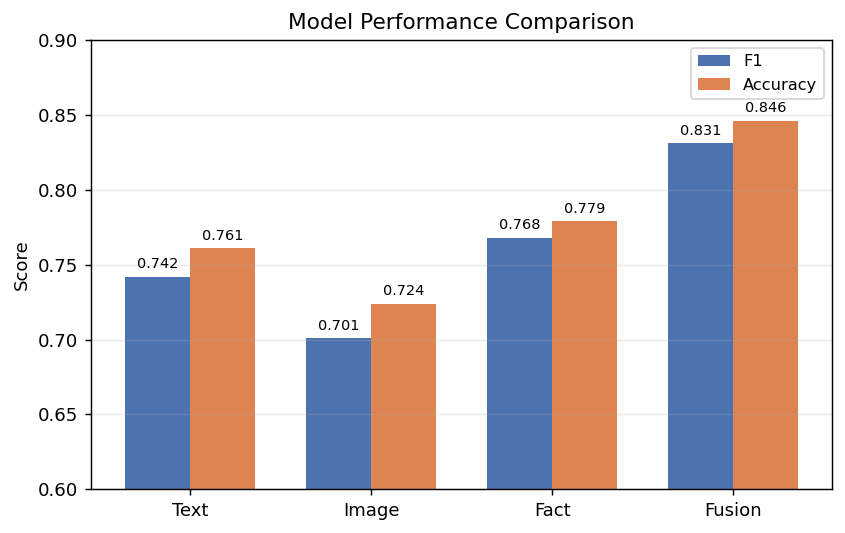

In [4]:
models = ["Text", "Image", "Fact", "Fusion"]
f1 = np.array([0.742, 0.701, 0.768, 0.831])
acc = np.array([0.761, 0.724, 0.779, 0.846])

x = np.arange(len(models))
width = 0.36
fig, ax = plt.subplots(figsize=(6.6, 4.2))
ax.bar(x - width / 2, f1, width, label="F1", color="#4C72B0")
ax.bar(x + width / 2, acc, width, label="Accuracy", color="#DD8452")
ax.set_xticks(x, models)
ax.set_ylim(0.60, 0.90)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.grid(axis="y", alpha=0.25)
ax.legend()

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "week1_model_bar.png")
plt.show()


## 4. ROC 曲线

ROC 曲线展示二分类模型在不同阈值下的真正率和假正率变化。曲线越靠近左上角，模型区分正负样本的能力越强；AUC 可以作为整体判别能力的汇总指标。

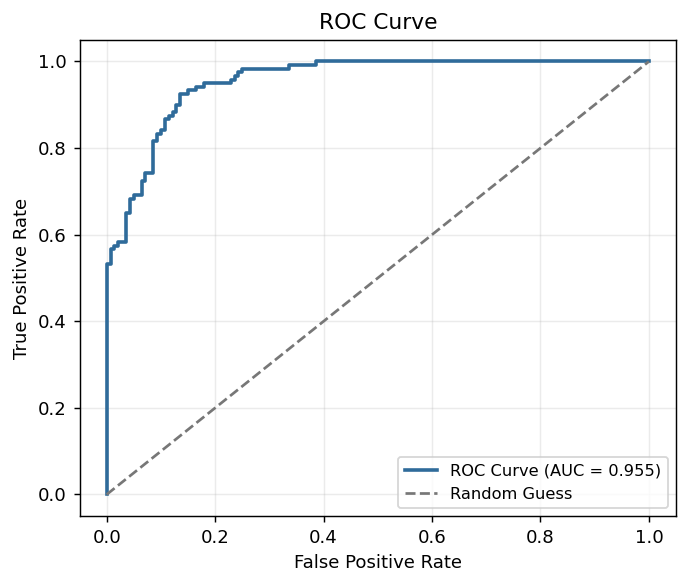

In [5]:
n_pos, n_neg = 120, 140
pos_scores = np.clip(np.random.normal(0.72, 0.16, n_pos), 0, 1)
neg_scores = np.clip(np.random.normal(0.34, 0.18, n_neg), 0, 1)
y_true = np.r_[np.ones(n_pos), np.zeros(n_neg)]
y_score = np.r_[pos_scores, neg_scores]

order = np.argsort(-y_score)
y_sorted = y_true[order]
tps = np.cumsum(y_sorted == 1)
fps = np.cumsum(y_sorted == 0)
tpr = np.r_[0, tps / n_pos, 1]
fpr = np.r_[0, fps / n_neg, 1]
auc = np.trapz(tpr, fpr)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.plot(fpr, tpr, linewidth=2, color="#2F6B9A", label=f"ROC Curve (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="#777777", label="Random Guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.grid(True, alpha=0.25)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "week1_roc_curve.png")
plt.show()


## 5. t-SNE 特征空间可视化

《实验室新生暑期居家集训学习计划》中的第 5 类图表是 t-SNE 特征空间可视化。这里用模拟的 128 维特征向量演示：先用 t-SNE 降到二维，再用散点图观察不同类别在特征空间中的分布。


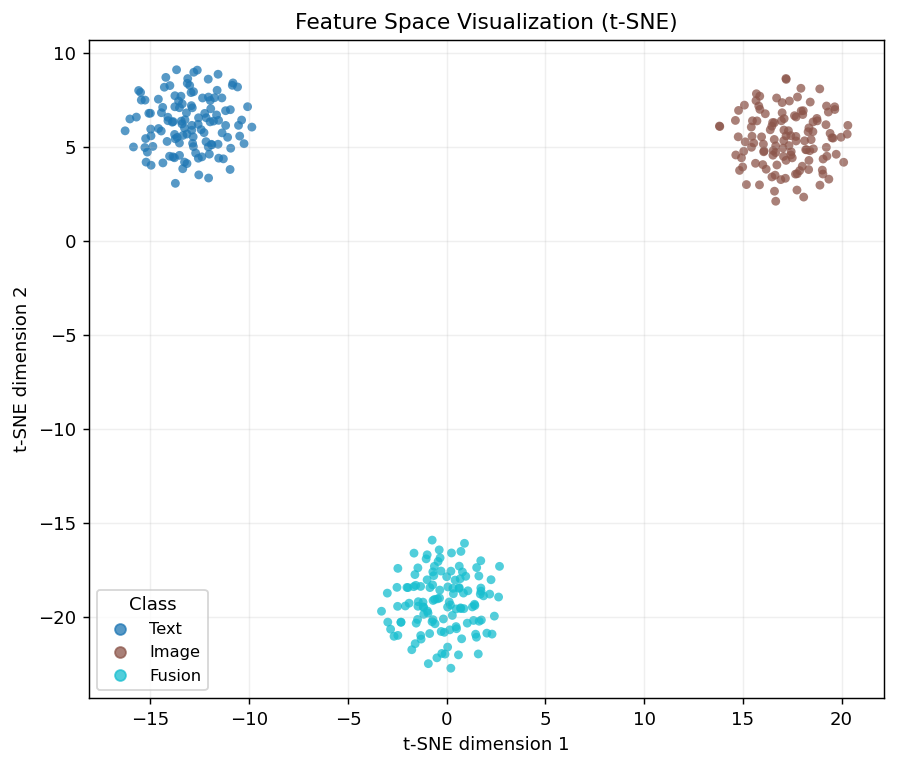

In [6]:
from sklearn.manifold import TSNE

rng = np.random.default_rng(42)
n_per_class = 120
feature_dim = 128
class_centers = np.array([
    np.r_[np.ones(16) * 2.0, np.zeros(feature_dim - 16)],
    np.r_[np.zeros(16), np.ones(16) * 2.0, np.zeros(feature_dim - 32)],
    np.r_[np.zeros(32), np.ones(16) * 2.0, np.zeros(feature_dim - 48)],
])
features = np.vstack([
    center + rng.normal(0, 0.8, size=(n_per_class, feature_dim))
    for center in class_centers
])
labels = np.repeat(["Text", "Image", "Fusion"], n_per_class)
label_ids = np.repeat([0, 1, 2], n_per_class)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
features_2d = tsne.fit_transform(features)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    features_2d[:, 0], features_2d[:, 1],
    c=label_ids, cmap="tab10", alpha=0.75, s=24, edgecolor="none"
)
handles, _ = scatter.legend_elements()
ax.legend(handles, ["Text", "Image", "Fusion"], title="Class", loc="best")
ax.set_title("Feature Space Visualization (t-SNE)")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig("../figures/week1_tsne.png", dpi=200, bbox_inches="tight")
plt.show()


## 小结

这五类图覆盖了实验论文中最常见的可视化需求：训练过程、分类错误分析、模型对比、二分类阈值评估和特征分布观察。对 Week1 来说，重点是能用 Notebook 组织代码、图表和解释，并把图片稳定导出到 `figures/` 目录。